# PoC: Visualização da Evolução das Features do Eclipse

Este notebook é uma prova de conceito (PoC) para explorar as métricas evolutivas geradas a partir da arquitetura LPS.
Ele demonstra como carregar o mapeamento das *releases* (JSON) e cruzar com os históricos de métricas (CSV), gerando visualizações para análise de complexidade e esforço de manutenção.

In [6]:
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais gerais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Definindo os Caminhos (Paths)

In [7]:
# 1. Caminhos para os diretórios de dados
base_dir = r"c:\Users\Kevin Strey\Desktop\Feature-models"
json_dir = os.path.join(base_dir, r"3-Mapeamento_features_simrel\simrel_mapper\output")
csv_dir = os.path.join(base_dir, r"2-JMethodsExtractor\target\results")

print("Diretório JSON:", json_dir)
print("Diretório CSV:", csv_dir)

Diretório JSON: c:\Users\Kevin Strey\Desktop\Feature-models\3-Mapeamento_features_simrel\simrel_mapper\output
Diretório CSV: c:\Users\Kevin Strey\Desktop\Feature-models\2-JMethodsExtractor\target\results


### Parse dos Mapeamentos (JSONs)
Primeiro, criamos um DataFrame geral contendo qual commit corresponde a qual feature em cada release do Eclipse SimRel.

In [8]:
# 2. Carregar mapeamentos (JSONs) para construir a linha do tempo das releases
json_files = glob.glob(os.path.join(json_dir, "*.json"))

timeline_data = []
for file_path in json_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        release_name = data.get('release')
        
        for feature, feature_data in data.get('mappings', {}).items():
            timeline_data.append({
                'release': release_name,
                'feature': feature,
                'commit': feature_data.get('commit'),
                'status': feature_data.get('status')
            })

df_timeline = pd.DataFrame(timeline_data)
# Ordenar alfabeticamente pelas releases (pode ser ajustado para ordenação temporal real)
df_timeline = df_timeline.sort_values(by='release').reset_index(drop=True)
df_timeline.head()

,release,feature,commit,status
0,2018-09,BIRT,0ae7df0fec104086ba7695f44316e8bf4d35fe77,SUCCESS
1,2018-09,Window Builder,571dc2a308dd38f285f46e4e3479c57c5dff781a,NEEDS REVIEW
2,2018-09,EclipseLink,3e83f76f7d4e7275d9d277a4375083ed0bd437d8,SUCCESS
3,2018-09,WebTools,5462e7660c53030225f2152353c94967fd5ebfb8,SUCCESS
4,2018-09,Subversive,88a4d1c24a1cda85b777dd8f73fa39e485018cac,NEEDS REVIEW


### Carga de Métricas de uma Feature Específica
Para esta PoC, vamos utilizar o histórico do **EGit** (que é menor, ~9MB) para exemplificar as visualizações sem sobrecarregar a memória.

In [9]:
# 3. Carregar CSV de uma Feature específica
feature_name = 'EGit'
csv_file = os.path.join(csv_dir, f"{feature_name}_history.csv")

print(f"Carregando base de métricas: {csv_file}")
df_metrics = pd.read_csv(csv_file)

# Exibir uma amostra dos dados (nível de método)
df_metrics.head(3)

Carregando base de métricas: c:\Users\Kevin Strey\Desktop\Feature-models\2-JMethodsExtractor\target\results\EGit_history.csv


,project,release,commit_index,commitHash,methodId,BOM,TACH,CHD,FCH,LCH,FRCH,WCH,WCD,CSB,CSBS,ACDF,LOC
0,EGit,JunoSR0,1,dfbdc456d8645fc0c310b5e15cf8d25d8ff7f84b,org.eclipse.egit.core.test/src/org/eclipse/egi...,1,0,"0,0000",0,0,0,"0,0000","0,0000",0,"0,0000","0,0000",18
1,EGit,JunoSR0,1,dfbdc456d8645fc0c310b5e15cf8d25d8ff7f84b,org.eclipse.egit.core.test/src/org/eclipse/egi...,1,0,"0,0000",0,0,0,"0,0000","0,0000",0,"0,0000","0,0000",13
2,EGit,JunoSR0,1,dfbdc456d8645fc0c310b5e15cf8d25d8ff7f84b,org.eclipse.egit.core.test/src/org/eclipse/egi...,1,0,"0,0000",0,0,0,"0,0000","0,0000",0,"0,0000","0,0000",9


In [10]:
# 4. Agregação das métricas por release
# Como os dados estão granulares (por método), agregamos para ver tendências gerais
df_agg = df_metrics.groupby('release').agg(
    total_methods=('methodId', 'count'),
    total_loc=('LOC', 'sum'),
    avg_loc=('LOC', 'mean'),
    avg_tach=('TACH', 'mean'),  # TACH = Total Amount of Changes
    avg_fch=('FCH', 'mean')     # FCH = Frequency of Changes
).reset_index()

df_agg.head()

,release,total_methods,total_loc,avg_loc,avg_tach,avg_fch
0,2018-09,535,16165,30.214953,4.183178,1949.854206
1,2018-12,490,12593,25.700000,4.620408,1544.934694
2,2019-03,365,11863,32.501370,5.978082,2249.841096
3,2019-06,629,19580,31.128776,6.025437,2508.124006
4,2019-09,296,9043,30.550676,6.263514,1675.226351


### Visualização 1: Gráfico de Linha (Série Temporal)
Mostra como o tamanho total do código fonte da feature (soma de LOC de todos os métodos) evoluiu nas diferentes versões.

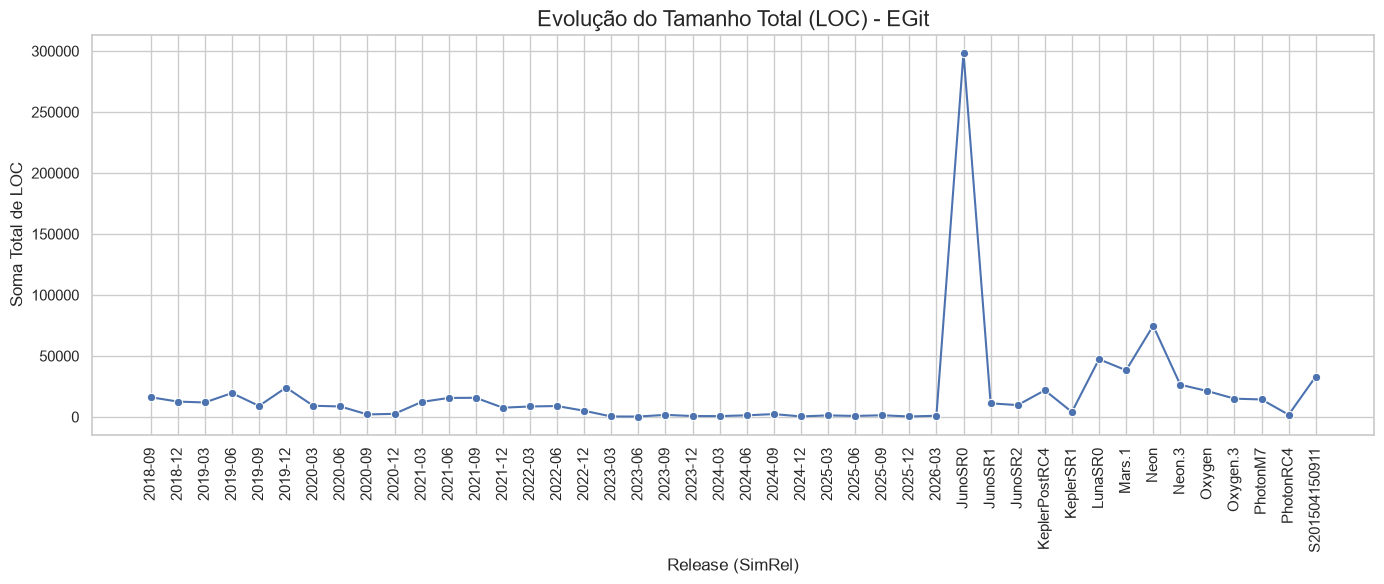

In [11]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_agg, x='release', y='total_loc', marker='o', color='b')

plt.title(f'Evolução do Tamanho Total (LOC) - {feature_name}', fontsize=16)
plt.xlabel('Release (SimRel)', fontsize=12)
plt.ylabel('Soma Total de LOC', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Visualização 2: Boxplot (Distribuição)
Ajuda a verificar se os métodos individualmente estão se tornando mais complexos (maiores). Escondemos os *outliers* (`showfliers=False`) para ver o miolo da distribuição.

C:\Users\Kevin Strey\AppData\Local\Temp\ipykernel_6772\4047229990.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_recent, x='release', y='LOC', showfliers=False, palette="Set2")


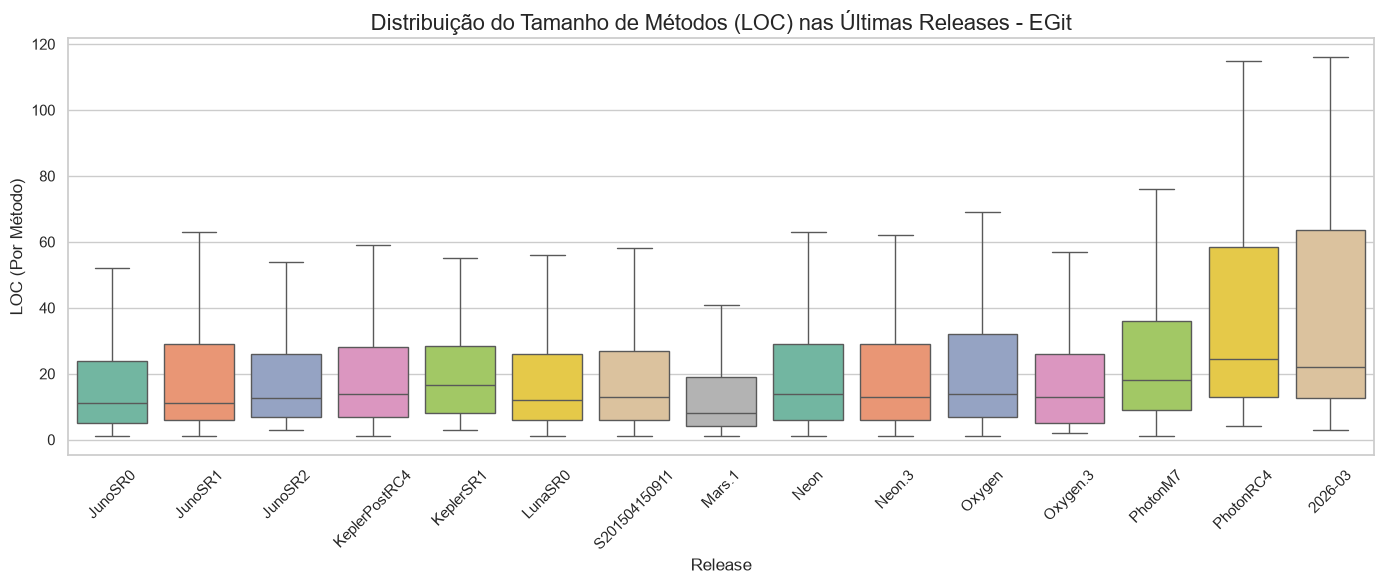

In [12]:
# Selecionar as últimas 15 releases (para não poluir o eixo X)
recent_releases = sorted(df_metrics['release'].unique())[-15:]
df_recent = df_metrics[df_metrics['release'].isin(recent_releases)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_recent, x='release', y='LOC', showfliers=False, palette="Set2")

plt.title(f'Distribuição do Tamanho de Métodos (LOC) nas Últimas Releases - {feature_name}', fontsize=16)
plt.xlabel('Release', fontsize=12)
plt.ylabel('LOC (Por Método)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualização 3: Scatter Plot em Quadrantes (Risco e Complexidade)
Cruzando Frequência de Mudança (FCH) x Tamanho (LOC) para identificar os "métodos vilões" (canto superior direito) em uma release específica.

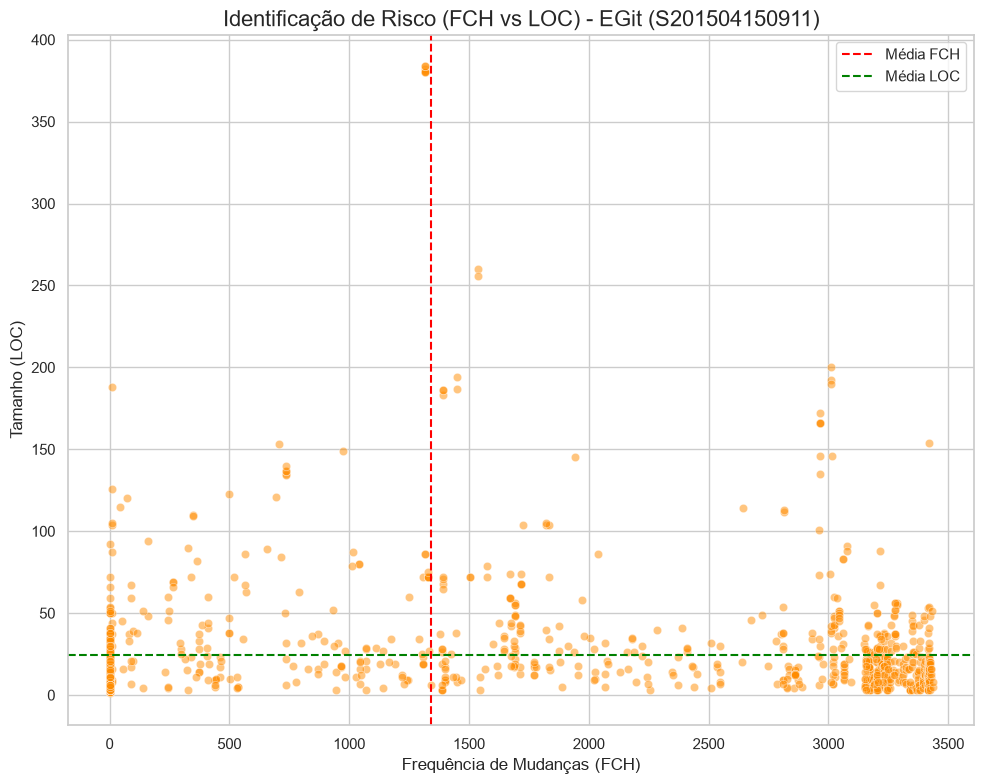

In [13]:
# Vamos analisar a release mais recente
last_release = sorted(df_metrics['release'].unique())[-1]
df_last = df_metrics[df_metrics['release'] == last_release]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_last, x='FCH', y='LOC', alpha=0.5, color='darkorange')

plt.title(f'Identificação de Risco (FCH vs LOC) - {feature_name} ({last_release})', fontsize=16)
plt.xlabel('Frequência de Mudanças (FCH)', fontsize=12)
plt.ylabel('Tamanho (LOC)', fontsize=12)

# Linhas de referência (Média)
plt.axvline(x=df_last['FCH'].mean(), color='red', linestyle='--', label='Média FCH')
plt.axhline(y=df_last['LOC'].mean(), color='green', linestyle='--', label='Média LOC')
plt.legend()

plt.tight_layout()
plt.show()